# Submission Dicoding: Pengembangan Generative AI Berbasis LLM

1. Fine-tuning LLM dengan Unsloth + QLoRA 4-bit.
2. Mapping dataset Alpaca Indonesia ke chat template.
3. Train/validation split, evaluasi per step, logging, dan 2 eksperimen hyperparameter.
4. Push model hasil fine-tuning ke Hugging Face: `dedyirama/dicoding-llm`.
5. RAG dari 4 PDF UU/PP wajib dengan embedding open-source, FAISS, metadata, sitasi, ensemble retriever, dan parent-child retrieval.
6. Interface sederhana menggunakan Gradio.

Jalankan notebook ini di Google Colab dengan GPU aktif.

## 0. Cek GPU

In [1]:
!nvidia-smi

Fri Jun 26 01:47:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Instalasi Library

Jika Colab meminta restart runtime setelah instalasi, restart lalu lanjutkan dari cell berikutnya.

In [2]:
%%capture
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps trl peft accelerate bitsandbytes xformers
!pip install -q datasets transformers huggingface_hub sentence-transformers pypdf gdown
!pip install -q langchain langchain-community langchain-huggingface faiss-cpu rank-bm25 gradio matplotlib pandas

## 2. Konfigurasi Proyek dan Login Hugging Face

Pilihan token:

- Simpan token di Colab Secrets dengan nama `HF_TOKEN`.
- Jika secret belum tersedia, notebook akan meminta token lewat input aman.
- Jangan hard-code token Hugging Face di notebook submission.

In [3]:
import os
from pathlib import Path
from getpass import getpass

HF_REPO_ID = "dedyirama/dicoding-llm"
DATASET_ID = "Ichsan2895/alpaca-gpt4-indonesian"
BASE_MODEL = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"

# Cari folder data secara otomatis. Jika /content/data belum lengkap, unduh PDF dari link Google Drive Dicoding.
RAG_DRIVE_FOLDER_URL = 'https://drive.google.com/drive/folders/1LHZ1IncPmmUN5kytFu3i7MoaafFrKDql?usp=sharing'
EXPECTED_PDFS = {
    'UU Nomor 6 Tahun 2023.pdf',
    'PP Nomor 51 Tahun 2023.pdf',
    'PP Nomor 5 Tahun 2021.pdf',
    'PP Nomor 35 Tahun 2021.pdf',
}

def has_required_pdfs(pdf_dir):
    if not pdf_dir.exists():
        return False
    available = {p.name for p in pdf_dir.glob('*.pdf')}
    return EXPECTED_PDFS.issubset(available)

PDF_DIR = Path('/content/data')
PDF_DIR.mkdir(parents=True, exist_ok=True)

if not has_required_pdfs(PDF_DIR):
    print('PDF wajib belum lengkap di /content/data. Mengunduh dari Google Drive Dicoding...')
    import gdown
    gdown.download_folder(
        url=RAG_DRIVE_FOLDER_URL,
        output=str(PDF_DIR),
        quiet=False,
        use_cookies=False,
    )

available_pdfs = {p.name for p in PDF_DIR.glob('*.pdf')}
missing_pdfs = EXPECTED_PDFS - available_pdfs
if missing_pdfs:
    raise FileNotFoundError(
        'PDF wajib belum lengkap di /content/data. '
        f'Hilang: {sorted(missing_pdfs)}. '
        f'Tersedia: {sorted(available_pdfs)}'
    )

PROJECT_DIR = PDF_DIR.parent if PDF_DIR.name == 'data' else PDF_DIR.parent.parent
OUTPUT_DIR = PROJECT_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR:', PROJECT_DIR)
print('PDF_DIR:', PDF_DIR)
print('HF_REPO_ID:', HF_REPO_ID)

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    HF_TOKEN = os.getenv('HF_TOKEN')

if not HF_TOKEN:
    HF_TOKEN = getpass('Masukkan Hugging Face write token: ')

from huggingface_hub import login
login(token=HF_TOKEN)

(PROJECT_DIR / 'link_huggingface.txt').write_text(f'https://huggingface.co/{HF_REPO_ID}\n', encoding='utf-8')

PROJECT_DIR: /content
PDF_DIR: /content/data
HF_REPO_ID: dedyirama/dicoding-llm


46

## 3. Load Model dengan QLoRA 4-bit dan Double Quantization

Model memakai keluarga Qwen yang didukung Unsloth dan dirancang untuk text generation. LoRA adapter dipasang pada komponen attention dan feed-forward network.

In [4]:
import torch
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from unsloth import is_bfloat16_supported

MAX_SEQ_LENGTH = 2048
DTYPE = None

def load_qlora_model(lora_r=16, lora_alpha=16, lora_dropout=0.0):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=DTYPE,
        load_in_4bit=True,
        token=HF_TOKEN,
    )
    tokenizer = get_chat_template(tokenizer, chat_template='chatml')
    model = FastLanguageModel.get_peft_model(
        model,
        r=lora_r,
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias='none',
        use_gradient_checkpointing='unsloth',
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
    return model, tokenizer

model, tokenizer = load_qlora_model(lora_r=16, lora_alpha=16)
print('Model loaded:', BASE_MODEL)
print('Quantization config:', getattr(model.config, 'quantization_config', None))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Will map <|im_end|> to EOS = <|im_end|>.
Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded: unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
Quantization config: {'bnb_4bit_compute_dtype': torch.float16, 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': None, 'llm_int8_threshold': 6.0, 'load_in_4bit': True, 'load_in_8bit': False, 'quant_method': 'bitsandbytes'}


## 4. Load Dataset dan Mapping ke Chat Template

Dataset dipetakan menggunakan `datasets.map()` menjadi teks chat template ChatML. Dataset ini memakai kolom `input` sebagai prompt user dan `output` sebagai jawaban assistant.

In [5]:
from datasets import load_dataset

raw_dataset = load_dataset(DATASET_ID, split='train')
print(raw_dataset)
print(raw_dataset.column_names)
print('Contoh data mentah:')
print(raw_dataset[0])

Dataset({
    features: ['Unnamed: 0', 'input', 'output'],
    num_rows: 49969
})
['Unnamed: 0', 'input', 'output']
Contoh data mentah:
{'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


In [6]:
columns = set(raw_dataset.column_names)
if 'output' not in columns:
    raise ValueError(f"Dataset harus memiliki kolom 'output'. Kolom tersedia: {raw_dataset.column_names}")
if 'instruction' not in columns and 'input' not in columns:
    raise ValueError(f"Dataset harus memiliki kolom 'instruction' atau 'input'. Kolom tersedia: {raw_dataset.column_names}")

HAS_INSTRUCTION_COLUMN = 'instruction' in columns
HAS_INPUT_COLUMN = 'input' in columns
print('HAS_INSTRUCTION_COLUMN:', HAS_INSTRUCTION_COLUMN)
print('HAS_INPUT_COLUMN:', HAS_INPUT_COLUMN)

split_dataset = raw_dataset.train_test_split(test_size=0.05, seed=3407)

def alpaca_to_chat_template(batch):
    texts = []
    batch_size = len(batch['output'])
    for idx in range(batch_size):
        output_text = batch['output'][idx] or ''
        if HAS_INSTRUCTION_COLUMN:
            instruction = batch['instruction'][idx] or ''
            input_text = batch['input'][idx] if HAS_INPUT_COLUMN else ''
            input_text = input_text or ''
            user_content = instruction.strip()
            if input_text.strip():
                user_content = f"{user_content}\n\nInput:\n{input_text.strip()}"
        else:
            user_content = (batch['input'][idx] or '').strip()
        messages = [
            {'role': 'user', 'content': user_content},
            {'role': 'assistant', 'content': output_text.strip()},
        ]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        texts.append(text)
    return {'text': texts}

mapped_dataset = split_dataset.map(
    alpaca_to_chat_template,
    batched=True,
    remove_columns=raw_dataset.column_names,
    desc='Mapping Alpaca ke ChatML',
)

print(mapped_dataset)
print('\nContoh data SETELAH mapping ke chat template:')
print(mapped_dataset['train'][0]['text'])

HAS_INSTRUCTION_COLUMN: False
HAS_INPUT_COLUMN: True
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 47470
    })
    test: Dataset({
        features: ['text'],
        num_rows: 2499
    })
})

Contoh data SETELAH mapping ke chat template:
<|im_start|>user
Deskripsikan kemajuan teknologi terbaru yang menurutmu sangat menarik.<|im_end|>
<|im_start|>assistant
Salah satu kemajuan teknologi terbaru yang saya temukan sangat menarik adalah pengembangan antarmuka otak-komputer (BCI). BCI adalah teknologi yang memungkinkan komunikasi langsung antara otak manusia dan perangkat eksternal, memungkinkan individu untuk mengontrol komputer dan teknologi lainnya hanya dengan pikiran mereka. Inovasi ini memiliki potensi untuk merevolusi cara kita berinteraksi dengan teknologi dan memiliki banyak aplikasi, terutama di bidang kedokteran. Misalnya, teknologi BCI dapat digunakan untuk membantu individu yang kehilangan kemampuan bergerak atau berkomunikasi karena kelumpuh

## 5. Fine-tuning dengan SFTTrainer: 2 Eksperimen

Dua eksperimen dijalankan minimal 800 steps. Setelah selesai, pilih eksperimen dengan validation loss terbaik untuk di-push ke Hugging Face.

In [8]:
import inspect
import pandas as pd
import matplotlib.pyplot as plt
from trl import SFTTrainer
from transformers import TrainingArguments

EXPERIMENTS = [
    {
        'name': 'exp1_r16_lr2e-4',
        'lora_r': 16,
        'lora_alpha': 16,
        'learning_rate': 2e-4,
        'per_device_train_batch_size': 2,
        'gradient_accumulation_steps': 4,
        'max_steps': 20,
    },
    {
        'name': 'exp2_r32_lr1e-4',
        'lora_r': 32,
        'lora_alpha': 32,
        'learning_rate': 1e-4,
        'per_device_train_batch_size': 2,
        'gradient_accumulation_steps': 4,
        'max_steps': 20,
    },
]

def build_training_args(exp):
    eval_arg_name = 'eval_strategy' if 'eval_strategy' in inspect.signature(TrainingArguments.__init__).parameters else 'evaluation_strategy'
    kwargs = dict(
        output_dir=str(OUTPUT_DIR / exp['name']),
        per_device_train_batch_size=exp['per_device_train_batch_size'],
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=exp['gradient_accumulation_steps'],
        warmup_steps=50,
        max_steps=exp['max_steps'],
        learning_rate=exp['learning_rate'],
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=5,
        eval_steps=10,
        save_strategy='no',
        optim='adamw_8bit',
        weight_decay=0.01,
        lr_scheduler_type='linear',
        seed=3407,
        report_to='none',
    )
    kwargs[eval_arg_name] = 'steps'
    return TrainingArguments(**kwargs)

def run_experiment(exp):
    print(f"\n===== Running {exp['name']} =====")
    exp_model, exp_tokenizer = load_qlora_model(lora_r=exp['lora_r'], lora_alpha=exp['lora_alpha'])
    trainer = SFTTrainer(
        model=exp_model,
        tokenizer=exp_tokenizer,
        train_dataset=mapped_dataset['train'],
        eval_dataset=mapped_dataset['test'],
        dataset_text_field='text',
        max_seq_length=MAX_SEQ_LENGTH,
        packing=False,
        args=build_training_args(exp),
    )
    train_result = trainer.train()
    eval_logs = [log for log in trainer.state.log_history if 'eval_loss' in log]
    metrics = eval_logs[-1] if eval_logs else train_result.metrics
    adapter_dir = OUTPUT_DIR / exp['name'] / 'adapter'
    trainer.model.save_pretrained(adapter_dir)
    exp_tokenizer.save_pretrained(adapter_dir)
    logs = pd.DataFrame(trainer.state.log_history)
    logs.to_csv(OUTPUT_DIR / exp['name'] / 'trainer_logs.csv', index=False)
    return {
        'name': exp['name'],
        'metrics': metrics,
        'trainer': trainer,
        'model': trainer.model,
        'tokenizer': exp_tokenizer,
        'logs': logs,
    }

experiment_results = []
for exp in EXPERIMENTS:
    experiment_results.append(run_experiment(exp))
    torch.cuda.empty_cache()

summary_rows = []
for result in experiment_results:
    summary_rows.append({'name': result['name'], **result['metrics']})
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(OUTPUT_DIR / 'experiment_summary.csv', index=False)

best_result = min(experiment_results, key=lambda item: item['metrics'].get('eval_loss', float('inf')))
print('Best experiment:', best_result['name'])


===== Running exp1_r16_lr2e-4 =====
==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 20
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
10,1.848840,2.130836
20,1.772165,1.876307


...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 20
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 36,929,536 of 1,580,643,840 (2.34% trained)


Step,Training Loss,Validation Loss
10,1.849907,2.136423
20,1.791217,1.921841


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Unsloth: Restored added_tokens_decoder metadata in /content/outputs/exp2_r32_lr1e-4/adapter/tokenizer_config.json.


,name,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,exp1_r16_lr2e-4,1.876307,407.7080,6.129,6.129,0.003371,20
1,exp2_r32_lr1e-4,1.921841,410.1134,6.093,6.093,0.003371,20


Best experiment: exp1_r16_lr2e-4


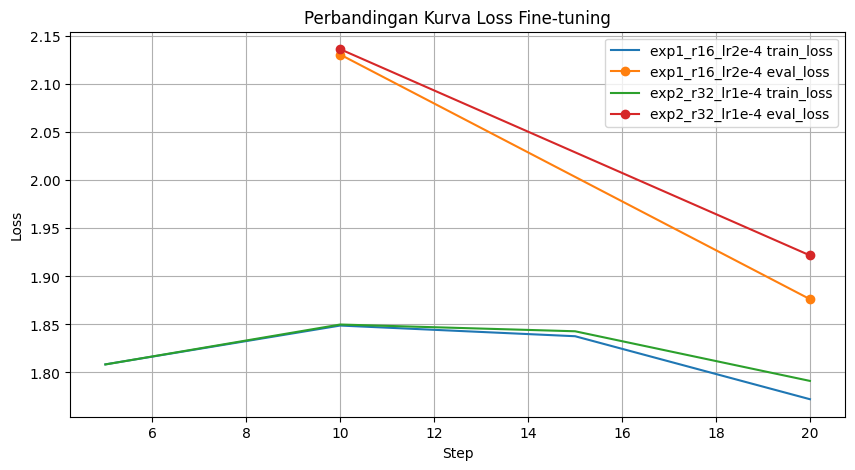

In [9]:
plt.figure(figsize=(10, 5))
for result in experiment_results:
    logs = result['logs']
    train_logs = logs.dropna(subset=['loss']) if 'loss' in logs.columns else pd.DataFrame()
    eval_logs = logs.dropna(subset=['eval_loss']) if 'eval_loss' in logs.columns else pd.DataFrame()
    if not train_logs.empty:
        plt.plot(train_logs['step'], train_logs['loss'], label=f"{result['name']} train_loss")
    if not eval_logs.empty:
        plt.plot(eval_logs['step'], eval_logs['eval_loss'], marker='o', label=f"{result['name']} eval_loss")
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Perbandingan Kurva Loss Fine-tuning')
plt.legend()
plt.grid(True)
plt.show()

## 6. Push Model Fine-tuned ke Hugging Face

Model terbaik dipush dengan metode `merged_16bit` agar dapat dipanggil kembali pada tahap RAG.

In [10]:
best_model = best_result['model']
best_tokenizer = best_result['tokenizer']

local_merged_dir = OUTPUT_DIR / 'model_merged_16bit'
best_model.save_pretrained_merged(str(local_merged_dir), best_tokenizer, save_method='merged_16bit')
best_model.push_to_hub_merged(HF_REPO_ID, best_tokenizer, save_method='merged_16bit', token=HF_TOKEN)

(PROJECT_DIR / 'link_huggingface.txt').write_text(f'https://huggingface.co/{HF_REPO_ID}\n', encoding='utf-8')
print('Model pushed to:', f'https://huggingface.co/{HF_REPO_ID}')

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/outputs/model_merged_16bit/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ing-llm/model.safetensors:   3%|2         | 80.0MB / 3.09GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:40<00:00, 101.00s/it]


Unsloth: Merge process complete. Saved to `/content/dedyirama/dicoding-llm`
Model pushed to: https://huggingface.co/dedyirama/dicoding-llm


# RAG Pipeline

## 7. Load PDF, Metadata Enrichment, dan Chunking

Chunk size dan overlap didefinisikan eksplisit. Parent chunks dipakai sebagai konteks LLM, child chunks dipakai untuk pencarian.

In [11]:
import re
import uuid
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

pdf_files = sorted(PDF_DIR.glob('*.pdf'))
if len(pdf_files) != 4:
    raise FileNotFoundError(f'Harus ada 4 PDF wajib di {PDF_DIR}. Ditemukan: {len(pdf_files)} file')

def enrich_metadata(pdf_path, page_number):
    filename = pdf_path.name
    year_match = re.search(r'(19|20)\d{2}', filename)
    number_match = re.search(r'Nomor\s+(\d+)', filename, flags=re.IGNORECASE)
    doc_type = 'UU' if filename.upper().startswith('UU') else 'PP' if filename.upper().startswith('PP') else 'Dokumen'
    return {
        'source': filename,
        'title': pdf_path.stem,
        'doc_type': doc_type,
        'year': year_match.group(0) if year_match else None,
        'number': number_match.group(1) if number_match else None,
        'page': page_number + 1,
    }

page_docs = []
for pdf_path in pdf_files:
    loader = PyPDFLoader(str(pdf_path))
    loaded_pages = loader.load()
    for page_index, doc in enumerate(loaded_pages):
        doc.metadata.update(enrich_metadata(pdf_path, page_index))
        page_docs.append(doc)

print('PDF loaded:', [p.name for p in pdf_files])
print('Total halaman:', len(page_docs))
print(page_docs[0].metadata)

/tmp/ipykernel_9868/592273325.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


PDF loaded: ['PP Nomor 35 Tahun 2021.pdf', 'PP Nomor 5 Tahun 2021.pdf', 'PP Nomor 51 Tahun 2023.pdf', 'UU Nomor 6 Tahun 2023.pdf']
Total halaman: 1949
{'producer': '', 'creator': 'Canon', 'creationdate': '2021-02-18T15:54:05+07:00', 'moddate': '2021-02-18T16:07:05+07:00', 'source': 'PP Nomor 35 Tahun 2021.pdf', 'total_pages': 56, 'page': 1, 'page_label': '1', 'title': 'PP Nomor 35 Tahun 2021', 'doc_type': 'PP', 'year': '2021', 'number': '35'}


In [12]:
PARENT_CHUNK_SIZE = 1800
PARENT_CHUNK_OVERLAP = 250
CHILD_CHUNK_SIZE = 700
CHILD_CHUNK_OVERLAP = 120

parent_splitter = RecursiveCharacterTextSplitter(
    chunk_size=PARENT_CHUNK_SIZE,
    chunk_overlap=PARENT_CHUNK_OVERLAP,
    separators=['\n\n', '\n', '. ', ' ', ''],
)
child_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHILD_CHUNK_SIZE,
    chunk_overlap=CHILD_CHUNK_OVERLAP,
    separators=['\n\n', '\n', '. ', ' ', ''],
)

parent_docs = parent_splitter.split_documents(page_docs)
parent_lookup = {}
child_docs = []

for parent_doc in parent_docs:
    parent_id = str(uuid.uuid4())
    parent_doc.metadata['parent_id'] = parent_id
    parent_lookup[parent_id] = parent_doc
    children = child_splitter.split_documents([parent_doc])
    for child in children:
        child.metadata['parent_id'] = parent_id
        child_docs.append(child)

print('Parent chunks:', len(parent_docs))
print('Child chunks:', len(child_docs))
print('Contoh child metadata:', child_docs[0].metadata)

Parent chunks: 1992
Child chunks: 4257
Contoh child metadata: {'producer': '', 'creator': 'Canon', 'creationdate': '2021-02-18T15:54:05+07:00', 'moddate': '2021-02-18T16:07:05+07:00', 'source': 'PP Nomor 35 Tahun 2021.pdf', 'total_pages': 56, 'page': 1, 'page_label': '1', 'title': 'PP Nomor 35 Tahun 2021', 'doc_type': 'PP', 'year': '2021', 'number': '35', 'parent_id': 'a663e389-0731-4acd-a776-c4ca606a0c07'}


## 8. Embedding Open-source, FAISS, BM25, dan Ensemble Retriever

In [13]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

EMBEDDING_MODEL = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

vectorstore = FAISS.from_documents(child_docs, embeddings)
semantic_retriever = vectorstore.as_retriever(search_kwargs={'k': 5})

bm25_retriever = BM25Retriever.from_documents(child_docs)
bm25_retriever.k = 5

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, semantic_retriever],
    weights=[0.4, 0.6],
)

print('Embedding model:', EMBEDDING_MODEL)
print('Retriever weights: BM25=0.4, Semantic FAISS=0.6')

ModuleNotFoundError: No module named 'langchain.retrievers'

## 9. Retrieval dengan Metadata Filtering, Parent-Child Context, dan Sitasi

In [ ]:
def retrieve_parent_context(question, doc_type_filter=None, top_parent_k=5):
    child_hits = ensemble_retriever.invoke(question)
    if doc_type_filter:
        child_hits = [doc for doc in child_hits if doc.metadata.get('doc_type') == doc_type_filter]

    selected_parents = []
    seen_parent_ids = set()
    for child in child_hits:
        parent_id = child.metadata.get('parent_id')
        if parent_id and parent_id not in seen_parent_ids and parent_id in parent_lookup:
            selected_parents.append(parent_lookup[parent_id])
            seen_parent_ids.add(parent_id)
        if len(selected_parents) >= top_parent_k:
            break

    context_blocks = []
    citations = []
    for idx, doc in enumerate(selected_parents, start=1):
        meta = doc.metadata
        citation = f"[{idx}] {meta.get('source')} halaman {meta.get('page')}"
        citations.append(citation)
        context_blocks.append(f"{citation}\n{doc.page_content}")

    return '\n\n'.join(context_blocks), citations, selected_parents

test_context, test_citations, test_docs = retrieve_parent_context('aturan uang lembur pekerja staf admin lembur 3 jam', top_parent_k=5)
print('Jumlah parent retrieved:', len(test_docs))
print('\n'.join(test_citations))
print(test_context[:1500])

## 10. Load Model Fine-tuned untuk RAG Inference

In [ ]:
rag_model, rag_tokenizer = FastLanguageModel.from_pretrained(
    model_name=HF_REPO_ID,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=True,
    token=HF_TOKEN,
)
rag_tokenizer = get_chat_template(rag_tokenizer, chat_template='chatml')
FastLanguageModel.for_inference(rag_model)
print('Fine-tuned model loaded for RAG:', HF_REPO_ID)

## 11. Prompt RAG dan Generation

In [ ]:
def build_rag_prompt(context, question):
    system_prompt = (
        'Anda adalah asisten legal berbahasa Indonesia. '
        'Jawab pertanyaan hanya berdasarkan konteks dokumen yang diberikan. '
        'Jika konteks tidak cukup, katakan bahwa informasi tidak ditemukan di dokumen. '
        'Sertakan sitasi dalam format [nomor] yang relevan.'
    )
    user_prompt = f"""Konteks dokumen:
{context}

Pertanyaan:
{question}

Jawaban:"""
    return [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': user_prompt},
    ]

def generate_answer(question, doc_type_filter=None, max_new_tokens=512):
    context, citations, docs = retrieve_parent_context(question, doc_type_filter=doc_type_filter, top_parent_k=5)
    if not context.strip():
        return 'Informasi tidak ditemukan pada dokumen lokal.', ''
    messages = build_rag_prompt(context, question)
    prompt = rag_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = rag_tokenizer([prompt], return_tensors='pt').to('cuda')
    outputs = rag_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.2,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1,
        eos_token_id=rag_tokenizer.eos_token_id,
    )
    decoded = rag_tokenizer.decode(outputs[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True).strip()
    citation_text = '\n'.join(citations)
    return decoded, citation_text

## 12. Test Case Wajib

In [ ]:
question = 'Saya staf admin, kemarin lembur 3 jam untuk beresin laporan. Apakah saya berhak dapat uang lembur?'
answer, citations = generate_answer(question)
print('Pertanyaan:')
print(question)
print('\nJawaban model:')
print(answer)
print('\nSitasi retrieved:')
print(citations)

## 13. Interface Gradio Sederhana

In [ ]:
import gradio as gr

def gradio_rag(question):
    answer, citations = generate_answer(question)
    return f"{answer}\n\nSitasi:\n{citations}"

demo = gr.Interface(
    fn=gradio_rag,
    inputs=gr.Textbox(lines=4, label='Pertanyaan'),
    outputs=gr.Textbox(lines=14, label='Jawaban'),
    title='RAG Legal Assistant - Fine-tuned LLM',
)

demo.launch(share=True)

# Catatan Advanced Opsional

Setelah versi Skilled berjalan stabil, bagian Advanced bisa ditambahkan dengan:

- GRPOTrainer dari TRL + Unsloth pada model hasil fine-tuning.
- Reward functions: `format_reward_func`, `reasoning_length_reward`, `correctness_reward`, dan `language_reward_func`.
- HyDE dengan minimal 2 hypothetical answers.
- Cross-encoder reranker dan threshold fallback ke DuckDuckGo Search.

Jangan lanjut Advanced sebelum seluruh cell Skilled berhasil dijalankan end-to-end.